# Création des Datasets pour LSTM (ISMN + ERA5)

Ce notebook est le point de passage final pour extraire les séries ISMN, filtrer et gérer les NaN, télécharger les données météorologiques locales via ERA5-Land (Earth Engine), aligner le tout et sauvegarder les séquences complètes sous forme de `.csv` prêts pour l'entraînement de notre LSTM.

In [1]:
%pip install ismn
%pip install pytesmo

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import matplotlib.pyplot as plt
import random
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from random import shuffle
from pytesmo.time_series.anomaly import calc_anomaly
from ismn.interface import ISMN_Interface

from Fcn_for_csv import (
    resample_timeseries,
    interpolate_timeseries,
    cut_timeseries,
    filter_outliers,
    find_abnormal_sequences,
    save_to_csv,
    get_meteo_data,
    detect_time_frequency,
    read_and_clean_data,
    create_clusters_dict,
    filter_data
    )

# Exemples de courbes entières

In [ ]:
ismn_raw_path = "/home/theodore/Documents/Get_Datasets/Data_separate_files_header_20160101_20260520_13465_BBMF_20260520"
ismn_data = ISMN_Interface(ismn_raw_path, parallel=True)

Using the existing ismn metadata in /home/theodore/Documents/Get_Datasets/Data_separate_files_header_20160101_20260520_13465_BBMF_20260520/python_metadata/Data_separate_files_header_20160101_20260520_13465_BBMF_20260520.csv to set up ISMN_Interface. 
If there are issues with the data reader, you can remove the metadata csv file to repeat metadata collection.


In [ ]:
sensor_list = filter_data(ismn_data=ismn_data, 
                          var = 'soil_moisture', 
                          Climate = ['Cfb'], 
                          land_cover = [10], 
                          frequency = 'H', 
                          depth_from = 0., 
                          depth_to = 0.15)

In [5]:
meta = sensor_list[0].metadata.to_pd()
print(meta) 

variable        key       
clay_fraction   val                          22.0
                depth_from                    0.0
                depth_to                      0.3
climate_KG      val                           Cfb
climate_insitu  val                       unknown
elevation       val                          39.0
instrument      val               Acclima-TDT_1_2
                depth_from                    0.1
                depth_to                      0.1
latitude        val                      52.86073
lc_2000         val                            10
lc_2005         val                            10
lc_2010         val                            10
longitude       val                      -1.12685
network         val                     COSMOS-UK
organic_carbon  val                          0.74
                depth_from                    0.0
                depth_to                      0.3
sand_fraction   val                          41.0
                depth_f

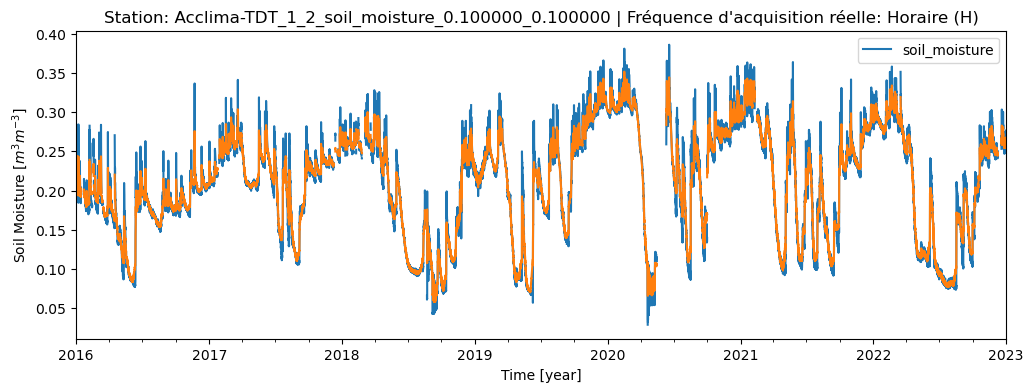

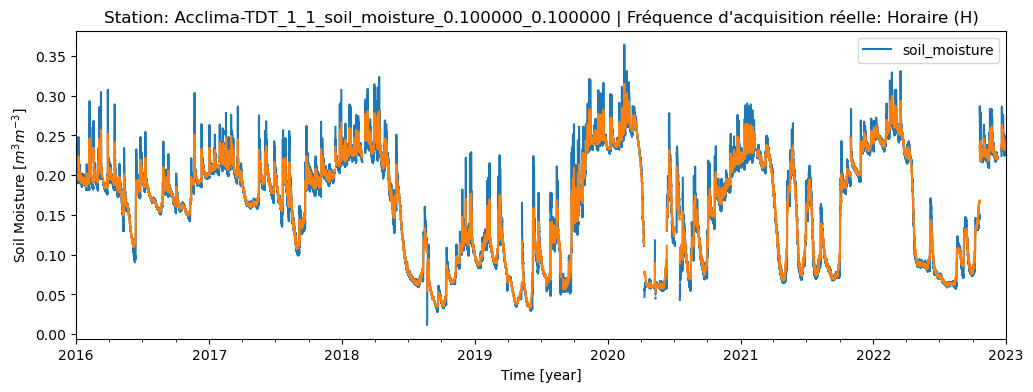

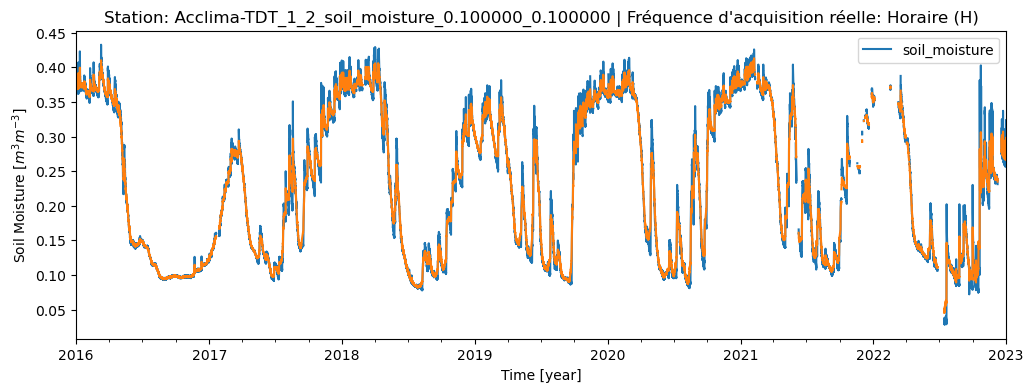

In [6]:
# Visualisation des séries temporelles de l'humidité du sol pour les stations avec :
# le label cropland (LC_2000 = 10) 
# et Climate_KG = 'Cfb'
compteur = 0

for sensor in sensor_list:

    data = read_and_clean_data(sensor)
    
    anomaly = data['soil_moisture'] - 0.5*calc_anomaly(data['soil_moisture'], window_size=15)
    freq = detect_time_frequency(data)

    if freq == 'H':
        compteur += 1
        plot_title = f"Station: {sensor} | Fréquence d'acquisition réelle: Horaire (H)"
        data.plot(y='soil_moisture', title=plot_title, figsize=(12, 4))
        anomaly.plot(y='soil_moisture', title=plot_title, figsize=(12, 4))
        plt.xlabel("Time [year]")
        plt.ylabel("Soil Moisture [$m^3 m^{-3}$]") 
        if compteur >= 3:
            break
    else :
        continue

In [7]:
clusters_dict, sensor_list, df_features = create_clusters_dict(sensor_list, method='soil_type', verbose=True)
n_clusters = len(clusters_dict)

Station: Acclima-TDT_1_2_soil_moisture_0.050000_0.050000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: Acclima-TDT_1_1_soil_moisture_0.050000_0.050000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: Acclima-TDT_1_1_soil_moisture_0.150000_0.150000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: Acclima-TDT_1_2_soil_moisture_0.150000_0.150000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: Acclima-TDT_1_2_soil_moisture_0.100000_0.100000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: Acclima-TDT_1_1_soil_moisture_0.100000_0.100000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: DeltaT-ThetaProbe-ML3_1_1_soil_moisture_0.050000_0.050000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: DeltaT-ThetaPro

In [8]:
from pytesmo.temporal_matching import temporal_collocation

# matched = temporal_collocation(df_ismn, df_satellite_or_local.set_index('DateTime'), window=1)    

# Processus de traitement des fichiers
0. Filtres : climat, années
1. Enregistrer les séries par sondes
+. Ajouter les données météos 
3. Valider les fichiers 1 par 1 (cf tri_courbes)
4. Ajouter les données topographiques
5. Ajouter les données satellites

+ Découpage, fréquence, interpolation...

# 0. Chargement et filtrage des fichiers

In [6]:
from ismn.interface import ISMN_Interface
from Fcn_for_csv import (
    filter_data, 
    read_and_clean_data, 
    )
import numpy as np
import pandas as pd
import os

In [ ]:
from Fcn_for_csv import (
    resample_timeseries,
    interpolate_timeseries,
    cut_timeseries,
    filter_outliers,
    find_abnormal_sequences,
    save_to_csv,
    get_meteo_data,
    get_meteo_data_hourly,
    detect_time_frequency,
    read_and_clean_data,
    create_clusters_dict,
    filter_data
    )

In [2]:
ismn_raw_path = "/home/theodore/Documents/Get_Datasets/Data_separate_files_header_20160101_20260520_13465_BBMF_20260520"
ismn_data = ISMN_Interface(ismn_raw_path, parallel=True)

sensor_list = filter_data(ismn_data=ismn_data, 
                          var = 'soil_moisture', 
                          Climate = ['Cfb'], 
                          land_cover = [10], 
                          frequency = 'H', 
                          depth_from = None, 
                          depth_to = None
                          )

Using the existing ismn metadata in /home/theodore/Documents/Get_Datasets/Data_separate_files_header_20160101_20260520_13465_BBMF_20260520/python_metadata/Data_separate_files_header_20160101_20260520_13465_BBMF_20260520.csv to set up ISMN_Interface. 
If there are issues with the data reader, you can remove the metadata csv file to repeat metadata collection.


# 1. Dossiers par sites (lat,lon) csv pour chaque sonde

+ csv pour relier le site aux métadonnées de la station 

+ tri par profondeur

In [ ]:
# ---------- CONFIGURATION ---------- #

BASE_DEST_DIR = r"/home/theodore/Documents/Get_Datasets/station_depth_csv"
MIN_LENGTH = 100  # Seuil de jours minimum continus sans NaN

compteur_fichiers = 0

# Structures pour le regroupement par station
stations_par_depth = {}      # (folder_depth, lat, lon) → station_id
prochains_id = {}            # folder_depth → prochain station_id
lignes_meta = {}             # folder_depth → [(station_id, lat, lon)]


cols_meta = ["station_id", "latitude", "longitude",
            "station_name", "network", "instrument"]


for sensor in sensor_list:

    df_full = read_and_clean_data(sensor)

    # Récupération sécurisée des métadonnées ISMN
    meta = sensor.metadata.to_pd()
    
    def get_meta(key, default=np.nan):
        return meta.get(key, default).val if key in meta else default

    lat, lon = get_meta('latitude'), get_meta('longitude')
    if pd.isna(lat) or pd.isna(lon):
        print(f"[{sensor}] Latitude/Longitude manquantes. Skip.")
        continue

    depth_from, depth_to = meta['variable'].depth_from, meta['variable'].depth_to

    df_full['Latitude'] = lat
    df_full['Longitude'] = lon
    df_full['Elevation'] = get_meta('elevation')
    df_full['Depth_from'] = depth_from
    df_full['Depth_to'] = depth_to
    df_full['Clay_fraction'] = get_meta('clay_fraction')
    df_full['Silt_fraction'] = get_meta('silt_fraction')
    df_full['Sand_fraction'] = get_meta('sand_fraction')
    df_full['Saturation'] = get_meta('saturation')
    df_full['Organic_carbon'] = get_meta('organic_carbon')
    
# ----------------- Ajout des données météorologiques ERA5  --------------------- #

    start_date = df_full.index.min().strftime('%Y-%m-%d')
    end_date = df_full.index.max().strftime('%Y-%m-%d')

    frequency = detect_time_frequency(df_full)
    if frequency == 'H':
        df_era5 = get_meteo_data_hourly(lat, lon, start_date, end_date)
    elif frequency == 'D':
        df_era5 = get_meteo_data(lat, lon, start_date, end_date)
    if not df_era5.empty:
        if 'WIND' in df_era5.columns:
            df_era5['WIND'] = df_era5['WIND'] * 0.748
        df_full = df_full.join(df_era5, how='inner')

    # Factorisation du processus de nommage des dossiers
    depth_thresholds = [0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95, 1.05]
    folder_depth = "depth_1.1_plus"
    for t in depth_thresholds:
        if depth_to <= t:
            folder_depth = f"depth_{t - 0.05:.1f}"
            break

    # ---------- Regroupement par station ---------- #
    cle = (folder_depth, lat, lon)

    if folder_depth not in prochains_id:
        prochains_id[folder_depth] = 1

    if cle not in stations_par_depth:
        station_id = prochains_id[folder_depth]
        stations_par_depth[cle] = station_id
        prochains_id[folder_depth] += 1
        lignes_meta.setdefault(folder_depth, []).append([
        station_id, lat, lon,
        get_meta('station'), get_meta('network'), get_meta('instrument')
        ])
    else:
        station_id = stations_par_depth[cle]


    dossier_station = os.path.join(BASE_DEST_DIR, folder_depth, f"station_{station_id}")
    os.makedirs(dossier_station, exist_ok=True)
    fichier_csv = os.path.join(dossier_station, f"{sensor}.csv")

    if os.path.exists(fichier_csv):
        raise FileExistsError(f"Fichier déjà existant : {fichier_csv}")

    df_full.to_csv(fichier_csv)

    print(f"[{compteur_fichiers+1}/{len(sensor_list)}] station_{station_id}/{sensor}")
    compteur_fichiers += 1


for folder, lignes in lignes_meta.items():
    chemin_meta = os.path.join(BASE_DEST_DIR, folder, "metadata.csv")
    os.makedirs(os.path.dirname(chemin_meta), exist_ok=True)
    pd.DataFrame(lignes, columns=cols_meta).to_csv(chemin_meta, index=False)
    
print(f"\n---\nTerminé ! {compteur_fichiers} sites traités avec succès.")
for folder, lignes in lignes_meta.items():
    print(f"  {folder}: {len(lignes)} station(s)")

[1/331] station_1/Acclima-TDT_1_2_soil_moisture_0.100000_0.100000
[2/331] station_1/Acclima-TDT_1_1_soil_moisture_0.100000_0.100000
[3/331] station_2/Acclima-TDT_1_2_soil_moisture_0.100000_0.100000
[4/331] station_2/Acclima-TDT_1_1_soil_moisture_0.100000_0.100000
[5/331] station_3/Acclima-TDT_1_2_soil_moisture_0.100000_0.100000
[6/331] station_3/Acclima-TDT_1_1_soil_moisture_0.100000_0.100000
[7/331] station_1/Acclima-TDT_1_1_soil_moisture_0.500000_0.500000
[8/331] station_1/Acclima-TDT_1_2_soil_moisture_0.500000_0.500000
[9/331] station_4/Acclima-TDT_1_2_soil_moisture_0.050000_0.050000
[10/331] station_4/Acclima-TDT_1_1_soil_moisture_0.050000_0.050000
[11/331] station_4/Acclima-TDT_1_1_soil_moisture_0.150000_0.150000
[12/331] station_4/Acclima-TDT_1_2_soil_moisture_0.100000_0.100000
[13/331] station_1/Acclima-TDT_1_2_soil_moisture_0.250000_0.250000
[14/331] station_4/Acclima-TDT_1_2_soil_moisture_0.150000_0.150000
[15/331] station_1/Acclima-TDT_1_1_soil_moisture_0.250000_0.250000
[16/

# 2.

In [ ]:

from Fcn_for_csv import get_meteo_data_hourly

BASE_DEST_DIR = "/home/theodore/Documents/Get_Datasets/station_depth_csv"

def get_station_meta(base_dir):
    """Lecture des metadata.csv par folder_depth"""
    stations = {}
    for folder in sorted(os.listdir(base_dir)):
        meta_path = os.path.join(base_dir, folder, "metadata.csv")
        if not os.path.exists(meta_path):
            continue
        df_meta = pd.read_csv(meta_path)
        stations[folder] = df_meta.set_index('station_id')[['latitude', 'longitude']].to_dict('index')
    return stations

def process_station(base_dir, folder, station_id, lat, lon):
    station_dir = os.path.join(base_dir, folder, f"station_{station_id}")
    if not os.path.isdir(station_dir):
        return

    csv_files = sorted([f for f in os.listdir(station_dir) if f.endswith('.csv')])
    if not csv_files:
        return

    # Date range global (min/max across all CSVs)
    global_start, global_end = None, None
    for fname in csv_files:
        df_temp = pd.read_csv(os.path.join(station_dir, fname), parse_dates=['date_time'])
        if global_start is None or df_temp['date_time'].min() < global_start:
            global_start = df_temp['date_time'].min()
        if global_end is None or df_temp['date_time'].max() > global_end:
            global_end = df_temp['date_time'].max()

    print(f"[{folder}/station_{station_id}] {lat:.4f}, {lon:.4f} | "
          f"{global_start:%Y-%m-%d} → {global_end:%Y-%m-%d} | {len(csv_files)} fichier(s)")

    # Téléchargement ERA5 unique pour toute la station
    df_era5 = get_meteo_data_hourly(lat, lon, global_start, global_end)
    if df_era5.empty:
        print(f"   Aucune donnée ERA5 pour cette station")
        return

    # Correction FAO vent
    if 'WIND' in df_era5.columns:
        df_era5['WIND'] = df_era5['WIND'] * 0.748

    # Application à chaque CSV
    for fname in csv_files:
        path = os.path.join(station_dir, fname)
        df_sensor = pd.read_csv(path, parse_dates=['date_time'])
        df_sensor.set_index('date_time', inplace=True)

        df_merged = df_sensor.join(df_era5, how='inner')
        if len(df_merged) == 0:
            print(f"   Aucune date commune pour {fname}, fichier ignoré")
            continue

        df_merged.to_csv(path, index=True, index_label='date_time')
        print(f"  ✓ {fname} → {len(df_merged)} lignes")

def main():
    stations = get_station_meta(BASE_DEST_DIR)
    for folder, station_dict in sorted(stations.items()):
        for station_id, coords in sorted(station_dict.items()):
            process_station(BASE_DEST_DIR, folder, station_id,
                            coords['latitude'], coords['longitude'])

if __name__ == '__main__':
    main()

In [9]:
# ---------- CONFIGURATION ---------- #

BASE_DEST_DIR = r"/home/theodore/Documents/Get_Datasets/csv_for_hrsm"
MIN_LENGTH = 100  # Seuil de jours minimum continus sans NaN

compteur_fichiers = 0

for sensor in sensor_list:

    df_full = read_and_clean_data(sensor)
    df_daily_mean = resample_timeseries(df_full, freq='D', method='mean', start_date='2016-01-01', end_date='2026-12-31')

    if df_daily_mean is None or df_daily_mean.empty:
        print(f"[{sensor}] Série temporelle vide après resampling. Skip.")
        continue

    df_interp = interpolate_timeseries(df_daily_mean)
    sequences = cut_timeseries(df_interp, min_length=MIN_LENGTH)

    if not sequences:
        print(f"[{sensor}] Aucune séquence continue de longueur >= {MIN_LENGTH} jours. Skip.")
        continue

    # 2. Récupération sécurisée des métadonnées ISMN
    meta = sensor.metadata.to_pd()
    
    # Fonction pour sécuriser l'extraction et éviter les requêtes de .val sur des objets nuls
    def get_meta(key, default=np.nan):
        return meta.get(key, default).val if key in meta else default

    lat = get_meta('latitude')
    lon = get_meta('longitude')
    elevation = get_meta('elevation')
    clay = get_meta('clay_fraction')
    silt = get_meta('silt_fraction')
    sand = get_meta('sand_fraction')
    saturation = get_meta('saturation')
    
    # La profondeur se récupère dans la variable spécifique
    
    depth_from = meta['variable'].depth_from
    depth_to = meta['variable'].depth_to

    if pd.isna(lat) or pd.isna(lon):
        print(f"[{sensor}] Latitude/Longitude manquantes. Skip.")
        continue

    # == OPTIMISATION: Télécharger ERA5 en une seule fois pour toute la plage dispo ! ==
    overall_start = sequences[0].index.min().strftime('%Y-%m-%d')
    overall_end = sequences[-1].index.max().strftime('%Y-%m-%d')
    
    df_era5_full = get_meteo_data(lat, lon, overall_start, overall_end)
    
    if not df_era5_full.empty:
        df_era5_full.index = pd.to_datetime(df_era5_full.index)
        # Profil vent logarithmique FAO (10m -> 2m standard agro)
        if 'WIND' in df_era5_full.columns:
            df_era5_full['WIND'] = df_era5_full['WIND'] * 0.748

    final_sequences = []
    
    # 3. Alignement avec la Météo ERA5 pour chaque séquence continue
    for seq in sequences:
        if df_era5_full.empty:
            continue
            
        # Fusion (Inner Join garantit qu'on garde que les jours valides des 2 côtés)
        df_merged = seq.join(df_era5_full, how='inner')
        
        if not df_merged.empty and len(df_merged) >= MIN_LENGTH:
            # Ajout de toutes les métadonnées statiques en colonnes
            df_merged['Latitude'] = lat
            df_merged['Longitude'] = lon
            df_merged['Elevation'] = elevation
            df_merged['Depth_from'] = depth_from
            df_merged['Depth_to'] = depth_to
            df_merged['Clay_fraction'] = clay
            df_merged['Silt_fraction'] = silt
            df_merged['Sand_fraction'] = sand
            df_merged['Saturation'] = saturation
            
            final_sequences.append(df_merged)

    # 4. Sauvegarde dans des sous-dossiers selon la profondeur
    if not pd.isna(depth_to) and final_sequences:
        
        # Factorisation du processus de nommage des dossiers
        depth_thresholds = [0.15, 0.25, 0.35, 0.45, 0.55, 0.65]
        folder_depth = "depth_0.7_plus"
        
        for t in depth_thresholds:
            if depth_to <= t:
                folder_depth = f"depth_{t - 0.05:.1f}"  # ex: 0.15-0.05 -> depth_0.1
                break
                
        dossier_destination = os.path.join(BASE_DEST_DIR, folder_depth, str(sensor))
        
        save_to_csv(final_sequences, dossier_destination)
        print(f"[{compteur_fichiers+1}/{len(sensor_list)}] {sensor} => {len(final_sequences)} séquence(s) sauvegardées.")
        compteur_fichiers += 1

print(f"\n---\nTerminé ! {compteur_fichiers} sites traités avec succès et enregistrés dans le dataset final.")

KeyboardInterrupt: 

In [1]:
import sys
import os
import glob
import pandas as pd
from Fcn_for_csv import get_topo_data

BASE_DEST_DIR = r"/home/theodore/Documents/Get_Datasets/Grandvillers_data"
OUTPUT_DEST_DIR = r"/home/theodore/Documents/Get_Datasets/Grandvillers_data/Grandvillers_topographie"
master_path = os.path.join(BASE_DEST_DIR, "Grandvillers_Soil_Properties_Master.csv")

get_topo_data(BASE_DEST_DIR, master_path, "Grandvillers")

4 fichiers CSV trouvés. Début de l'extraction des propriétés du sol...

[Grandvillers] Nouvelles coordonnées (2.6203, 49.4727) -> Téléchargement & calcul...
[1/4] Grandvillers  
[Grandvillers-Canon.csv] Coordonnées (2.6203, 49.4727) connues -> Récupération depuis le cache.
[2/4] Grandvillers-Canon.csv  
[Grandvillers-Robot.csv] Coordonnées (2.6203, 49.4727) connues -> Récupération depuis le cache.
[3/4] Grandvillers-Robot.csv  
[Grandvillers-Robot-20.csv] Coordonnées (2.6203, 49.4727) connues -> Récupération depuis le cache.
[4/4] Grandvillers-Robot-20.csv  

Extraction terminée ! Fichier maître sauvegardé ici : /home/theodore/Documents/Get_Datasets/Grandvillers_data/Grandvillers_Soil_Properties_Master.csv


In [ ]:
import os
import pandas as pd
import numpy as np
import ee
import requests
import tempfile
import rasterio
from Fcn_for_csv import compute_and_save_terrain_attributes

# Initialisation de GEE
try:
    ee.Initialize()
except Exception as e:
    print("Authentification à Google Earth Engine...")
    ee.Authenticate()
    ee.Initialize()


print("--- EXÉCUTION DU PATCH DEM AVEC GEE (JAXA ALOS) + WHITEBOX TOOLS ---")
df_all_sites_soil = pd.read_csv("/home/theodore/Documents/Get_Datasets/csv_for_hrsm/ISMN_Soil_Properties_Master.csv")
df_missing_topo = df_all_sites_soil[df_all_sites_soil['dem_twi'].isna() | df_all_sites_soil['dem_slope'].isna() | df_all_sites_soil['dem_aspect'].isna()]

# Identifier les sites manquants uniques
missing_coords = df_missing_topo[['latitude', 'longitude']].drop_duplicates()

# Charger le DEM de la JAXA via GEE
dem = ee.ImageCollection("JAXA/ALOS/AW3D30/V4_1").select('DSM').mosaic()

# On stocke les résultats
dem_patch_results = {}

for _, row in missing_coords.iterrows():
    lat = row['latitude']
    lon = row['longitude']
    
    print(f"\nCorrection pour (lat={lat}, lon={lon})...")
    try:
        # Créer une bounding box autour du point pour l'analyse topographique
        buffer_deg = 0.02
        bbox = ee.Geometry.Rectangle([lon - buffer_deg, lat - buffer_deg, lon + buffer_deg, lat + buffer_deg])
        
        # Récupérer l'URL de téléchargement direct du GeoTIFF
        url = dem.getDownloadURL({
            'scale': 30,
            'crs': 'EPSG:4326',
            'region': bbox,
            'format': 'GEO_TIFF'
        })
        
        # Télécharger et traiter en local
        response = requests.get(url)
        with tempfile.TemporaryDirectory() as tmp_dir:
            raw_dem_path = os.path.join(tmp_dir, "raw_dem.tif")
            dem_path = os.path.join(tmp_dir, "dem.tif")
            with open(raw_dem_path, "wb") as f:
                f.write(response.content)
            
            # WhiteboxTools est très stricte sur le format des fichiers. 
            # Les TIF de GEE contiennent souvent des métadonnées ou compressions qu'il n'aime pas.
            # On ré-écrit le TIF proprement via rasterio avant de lui passer.
            with rasterio.open(raw_dem_path) as src:
                data = src.read(1)
                profile = src.profile.copy()
                data = data.astype('float32') # Float32 est plus standard pour algorithmes topographiques
                profile.update(dtype='float32', compress='lzw', nodata=-9999.0)
            
            with rasterio.open(dem_path, 'w', **profile) as dst:
                dst.write(data, 1)
            
            topo_data = {}
            # Lire l'élévation au centre
            with rasterio.open(dem_path) as src:
                val = next(src.sample([(lon, lat)]))[0]
                topo_data['dem_m_30m_depth'] = val
                
            # Calculer slope, aspect, TWI avec WhiteboxTools
            output_records = compute_and_save_terrain_attributes(dem_path, verbose=True)
            
            for rec in output_records:
                attr_name = rec["output_stem"].split('_')[-1] # slope, aspect ou twi
                with rasterio.open(rec['local_path']) as src:
                    val = next(src.sample([(lon, lat)]))[0]
                    topo_data[f'dem_{attr_name}'] = val
            
        print(f" Attributs extraits: {topo_data}")
        dem_patch_results[(lat, lon)] = topo_data
        
    except Exception as e:
        print(f" Erreur pour ({lat}, {lon}): {e}")

# Mise à jour de df_all_sites_soil
for index, row in df_all_sites_soil.iterrows():
    lat = row['latitude']
    lon = row['longitude'] 
    
    # Si on a un résultat calculé
    if tuple([lat, lon]) in dem_patch_results:
        res = dem_patch_results[(lat, lon)]
        print(f"\nMise à jour pour index {index} (lat={lat}, lon={lon})...")
        if res:
            df_all_sites_soil.at[index, 'dem_m_30m_depth'] = res.get('dem_m_30m_depth', np.nan)
            df_all_sites_soil.at[index, 'dem_slope'] = res.get('dem_slope', np.nan)
            df_all_sites_soil.at[index, 'dem_aspect'] = res.get('dem_aspect', np.nan)
            df_all_sites_soil.at[index, 'dem_twi'] = res.get('dem_twi', np.nan)

print("\n--- PATCH TERMINE ---")
print("Vérification des lignes restantes avec des NaN (devrait être vide si tout a réussi) :")
print(df_all_sites_soil[df_all_sites_soil['dem_twi'].isna()])

# Sauvegarder à nouveau le master csv pour valider le correctif
export_path = '/home/theodore/Documents/Get_Datasets/csv_for_hrsm/ISMN_Soil_Properties_Master.csv'
df_all_sites_soil.to_csv(export_path, index=False)
print(f"Sauvegardé avec correctifs dans {export_path}")

--- EXÉCUTION DU PATCH DEM AVEC GEE (JAXA ALOS) + WHITEBOX TOOLS ---

Correction pour (lat=-34.72125, lon=173.04782)...
    Calcul des attributs de terrain pour dem.tif...
      ✓ SLOPE: /tmp/tmp6mtarf1s/dem_slope.tif (0.09 MB)
      ✓ ASPECT: /tmp/tmp6mtarf1s/dem_aspect.tif (0.09 MB)
      ✓ TWI: /tmp/tmp6mtarf1s/dem_twi.tif (0.09 MB)
✅ Attributs extraits: {'dem_m_30m_depth': np.float32(46.0), 'dem': np.float32(46.0), 'dem_slope': np.float32(2.514076), 'dem_aspect': np.float32(332.4617), 'dem_twi': np.float32(-3.1473725)}

Correction pour (lat=-36.70378, lon=174.55472)...
    Calcul des attributs de terrain pour dem.tif...
      ✓ SLOPE: /tmp/tmpsrbyvwls/dem_slope.tif (0.09 MB)
      ✓ ASPECT: /tmp/tmpsrbyvwls/dem_aspect.tif (0.09 MB)
      ✓ TWI: /tmp/tmpsrbyvwls/dem_twi.tif (0.09 MB)
✅ Attributs extraits: {'dem_m_30m_depth': np.float32(47.0), 'dem': np.float32(47.0), 'dem_slope': np.float32(9.49905), 'dem_aspect': np.float32(84.27713), 'dem_twi': np.float32(-6.4311485)}

Correction 

# Prendre les csv et ajouter / Compléter les colonnes 

In [1]:
import glob
import os
import pandas as pd
import numpy as np
from Fcn_for_csv import update_local_csv_with_master

BASE_DEST_DIR = r"/home/theodore/Documents/Get_Datasets/Grandvillers_data"
OUTPUT_DEST_DIR = r"/home/theodore/Documents/Get_Datasets/Grandvillers_data/Grandvillers_topographie"
master_path = os.path.join(BASE_DEST_DIR, "Grandvillers_Soil_Properties_Master.csv")


df_master = pd.read_csv(master_path)
csv_files = glob.glob(os.path.join(BASE_DEST_DIR, "*", "*.csv"))


print(f"{len(csv_files)} fichiers CSV de séries temporelles trouvés. Début du test...\n")

# Depth < 30cm -> On prend les propriétés du sol à 30cm de profondeur (car c'est la plus proche de la réalité du capteur)
colonnes=["dem_m_30m_depth", "bulk_m_30m_0cm_30cm", "sand_m_30m_0cm_30cm", "silt_m_30m_0cm_30cm", 
          "clay_m_30m_0cm_30cm", "ksat_m_1km_0cm", "dem_slope", "dem_aspect", "dem_twi"]

csv_folder = OUTPUT_DEST_DIR
#os.path.join(OUTPUT_DEST_DIR, "depth_0.1")
os.makedirs(csv_folder, exist_ok=True)


4 fichiers CSV de séries temporelles trouvés. Début du test...



In [2]:

for csv_file in csv_files:
    print(csv_file)
    df = update_local_csv_with_master(csv_file, df_master, cols=colonnes, coordonnees = "Grandvillers", verbose=False)

    new_csv_path = os.path.join(csv_folder, os.path.basename(csv_file))
    df.to_csv(new_csv_path, index=False)
    print(f" {os.path.basename(csv_file)} -> {os.path.basename(new_csv_path)} (colonnes mises à jour : {', '.join(colonnes)})")

/home/theodore/Documents/Get_Datasets/Grandvillers_data/raw/Grandvillers_Sec.csv
 Grandvillers_Sec.csv -> Grandvillers_Sec.csv (colonnes mises à jour : dem_m_30m_depth, bulk_m_30m_0cm_30cm, sand_m_30m_0cm_30cm, silt_m_30m_0cm_30cm, clay_m_30m_0cm_30cm, ksat_m_1km_0cm, dem_slope, dem_aspect, dem_twi)
/home/theodore/Documents/Get_Datasets/Grandvillers_data/raw/Grandvillers-Canon.csv
 Grandvillers-Canon.csv -> Grandvillers-Canon.csv (colonnes mises à jour : dem_m_30m_depth, bulk_m_30m_0cm_30cm, sand_m_30m_0cm_30cm, silt_m_30m_0cm_30cm, clay_m_30m_0cm_30cm, ksat_m_1km_0cm, dem_slope, dem_aspect, dem_twi)
/home/theodore/Documents/Get_Datasets/Grandvillers_data/raw/Grandvillers-Robot.csv
 Grandvillers-Robot.csv -> Grandvillers-Robot.csv (colonnes mises à jour : dem_m_30m_depth, bulk_m_30m_0cm_30cm, sand_m_30m_0cm_30cm, silt_m_30m_0cm_30cm, clay_m_30m_0cm_30cm, ksat_m_1km_0cm, dem_slope, dem_aspect, dem_twi)
/home/theodore/Documents/Get_Datasets/Grandvillers_data/raw/Grandvillers-Robot-20.csv

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import ee
ee.Authenticate()
ee.Initialize(project="projet-hrms")

In [4]:
def bitwiseExtract(img, fromBit, toBit):
  maskSize = ee.Number(1).add(toBit).subtract(fromBit)
  mask = ee.Number(1).leftShift(maskSize).subtract(1)
  return img.rightShift(fromBit).bitwiseAnd(mask)

# remove low quality data
def maskHLSL30(image):
  qcDay = image.select('Fmask')
  cloud = bitwiseExtract(qcDay, 1, 1).eq(0)
  cloudshadow = bitwiseExtract(qcDay, 3, 3).eq(0)
  snowice = bitwiseExtract(qcDay, 4, 4).eq(0)
  water = bitwiseExtract(qcDay, 5, 5).eq(0)
  aerosol = bitwiseExtract(qcDay, 6, 7).lte(2)
  mask = cloud.And(cloudshadow).And(snowice).And(water).And(aerosol)

  return    image.updateMask(mask).copyProperties(image, ['system:time_start'])

def maskSentinel2(img):
  # Get the pixel QA band.
  scl = img.select('SCL')
  mask = scl.neq(8).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))
  return img.updateMask(mask).copyProperties(img, ['system:time_start'])


def preprocess_vv(image):
    vv_masked = image.updateMask(image.gt(-20).And(image.lt(-5)))
    vv_filtered = vv_masked.convolve(ee.Kernel.gaussian(3))
    return vv_filtered #.rename('VV').copyProperties(image, ['system:time_start'])

# Define preprocessing for VH
def preprocess_vh(image):
    vh_masked = image.updateMask(image.gt(-30).And(image.lt(-10)))
    vh_filtered = vh_masked.convolve(ee.Kernel.gaussian(3))
    return vh_filtered #.rename('VH').copyProperties(image, ['system:time_start'])


def merge_bands(image):
    vv = image.select('VV')
    vh = image.select('VH')
    angle = image.select('angle')

    vv_prep = preprocess_vv(vv)      # Apply mask + smoothing to VV
    vh_prep = preprocess_vh(vh)      # Apply mask + smoothing to VH

    merged = vv_prep.addBands(vh_prep).addBands(angle.rename('angle'))

    return merged.copyProperties(image, ['system:time_start'])

def to_float(image):
    all_bands = image.bandNames()
    return image.select(all_bands).float().copyProperties(image, ['system:time_start'])

# --- 2. FONCTION D'EXTRACTION VERS PANDAS ---
def extract_time_series_to_pandas(collection, point, scale=10):
    """ Filtre la collection sur le point, extrait les valeurs et convertit en DataFrame """
    # getRegion extrait les valeurs de chaque image de la collection pour la géométrie donnée
    info = collection.getRegion(point, scale).getInfo()
    
    if len(info) > 1:
        header = info[0]
        data = info[1:]
        df = pd.DataFrame(data, columns=header)
        
        # Le timestamp GEE est en millisecondes, on le convertit en datetime Pandas
        if 'time' in df.columns:
            df['datetime'] = pd.to_datetime(df['time'], unit='ms')
            df.set_index('datetime', inplace=True)
            df = df.sort_index()
            # On retire les colonnes inutiles pour l'affichage
            colonnes_a_garder = [c for c in df.columns if c not in ['id', 'longitude', 'latitude', 'time']]
            return df[colonnes_a_garder]
    return pd.DataFrame()

In [5]:

def get_satellite_data_for_point(lon, lat, start_date, end_date):
    """
    Interroge GEE pour 1 point précis et renvoie un DataFrame Pandas regroupé par jour, 
    avec les bandes S1, S2 et HLSL30.
    """
    roi_point = ee.Geometry.Point([lon, lat])
    
    # 1. Création des requêtes GEE
    s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(roi_point).filterDate(start_date, end_date)
      .map(maskSentinel2)
      .select(['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']))
    
    s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
          .filterBounds(roi_point).filterDate(start_date, end_date)
          .filter(ee.Filter.eq('instrumentMode', 'IW'))
          .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
          .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
          .map(merge_bands).map(to_float))
    
    hls = (ee.ImageCollection("NASA/HLS/HLSL30/v002")
           .filterBounds(roi_point).filterDate(start_date, end_date)
           .map(maskHLSL30)
           .select(['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B9', 'B10', 'B11']))
    
    # 2. Récupération des DataFrames Pandas
    df_s2 = extract_time_series_to_pandas(s2, roi_point, scale=10)
    df_s1 = extract_time_series_to_pandas(s1, roi_point, scale=10)
    df_hls = extract_time_series_to_pandas(hls, roi_point, scale=30)
    
    # 3. Traitements S2
    if not df_s2.empty:
        df_s2 = df_s2.apply(pd.to_numeric, errors='coerce')
        df_s2['NDVI'] = (df_s2['B8'] - df_s2['B4']) / (df_s2['B8'] + df_s2['B4'])
        # Ramener le timestamp horaire à l'échelle journalière :
        df_s2.index = df_s2.index.normalize() 
        df_s2 = df_s2.groupby(df_s2.index).mean() # Moyenne si 2 passages le même jour
        df_s2 = df_s2.add_prefix('S2_')
        
    # 3. Traitements S1
    if not df_s1.empty:
        df_s1 = df_s1.apply(pd.to_numeric, errors='coerce')
        df_s1.index = df_s1.index.normalize()
        df_s1 = df_s1.groupby(df_s1.index).mean()
        df_s1 = df_s1.add_prefix('S1_')
        
    # 3. Traitements HLS
    if not df_hls.empty:
        df_hls = df_hls.apply(pd.to_numeric, errors='coerce')
        df_hls['NDVI'] = (df_hls['B5'] - df_hls['B4']) / (df_hls['B5'] + df_hls['B4'])
        df_hls.index = df_hls.index.normalize()
        df_hls = df_hls.groupby(df_hls.index).mean()
        df_hls = df_hls.add_prefix('HLS_')
        
    # 4. Assemblage global des 3 satellites
    df_sat = pd.DataFrame()
    if not df_s2.empty: df_sat = df_s2
    if not df_s1.empty: df_sat = df_sat.join(df_s1, how='outer') if not df_sat.empty else df_s1
    if not df_hls.empty: df_sat = df_sat.join(df_hls, how='outer') if not df_sat.empty else df_hls
        
    return df_sat


def enrich_csv_with_satellites(csv_path, output_dir, coordonnees ):
    """
    Lit un CSV d'entraînement existant, ajoute les colonnes satellites,
    les valeurs manquantes restent à NaN, et sauvegarde le nouveau dataset.
    """
    print(f"Traitement de {os.path.basename(csv_path)}")
    df = pd.read_csv(csv_path)
    
    # Identifier la colonne de temps (souvent la première)
    time_col = df.columns[0]
    df[time_col] = pd.to_datetime(df[time_col])
    df.set_index(time_col, inplace=True)
    
    # Extraire les coordonnées et la période
    if coordonnees == "Grandvillers":
        lat=49.4727
        lon=2.6203
    else:
        lat = df['Latitude'].iloc[0]
        lon = df['Longitude'].iloc[0]
    # On ajoute une petite marge temporelle pour encadrer
    start_date = (df.index.min() - pd.Timedelta(days=5)).strftime('%Y-%m-%d')
    end_date = (df.index.max() + pd.Timedelta(days=5)).strftime('%Y-%m-%d')
    
    print(f"  > Requete GEE pour lat:{lat:.3f} lon:{lon:.3f} de {start_date} à {end_date}...")
    df_sat = get_satellite_data_for_point(lon, lat, start_date, end_date)
    
    if df_sat.empty:
        print("   Aucune donnée satellite trouvée pour cette période/coordonnée.")
        df_final = df
    else:
        # Jointure à gauche sur le dataset quotidien existant : les trous resteront des NaN
        df_final = df.join(df_sat, how='left')

    # 3. Sauvegarde
    os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, os.path.basename(csv_path))
    df_final.reset_index().to_csv(out_path, index=False)
    print(f"   Fichier sauvegardé : {out_path}\n")
    return df_final


In [6]:
# INPUT_DIR = r"/home/theodore/Documents/Get_Datasets/csv_meteo_and_soil/depth_0.1"
# OUTPUT_DIR  = r"/home/theodore/Documents/Get_Datasets/satellites_ready"


INPUT_DIR = r"/home/theodore/Documents/Get_Datasets/Grandvillers_data/Grandvillers_topographie"
OUTPUT_DIR = r"/home/theodore/Documents/Get_Datasets/Grandvillers_data/Grandvillers_satellites"

csv_list = glob.glob(os.path.join(INPUT_DIR, "*.csv"))

for csv_file in csv_list: 
    enrich_csv_with_satellites(csv_file, OUTPUT_DIR, "Grandvillers")

Traitement de Grandvillers_Sec.csv
  > Requete GEE pour lat:49.473 lon:2.620 de 2025-04-30 à 2025-09-01...
   Fichier sauvegardé : /home/theodore/Documents/Get_Datasets/Grandvillers_data/Grandvillers_satellites/Grandvillers_Sec.csv

Traitement de Grandvillers-Canon.csv
  > Requete GEE pour lat:49.473 lon:2.620 de 2025-04-30 à 2025-09-02...
   Fichier sauvegardé : /home/theodore/Documents/Get_Datasets/Grandvillers_data/Grandvillers_satellites/Grandvillers-Canon.csv

Traitement de Grandvillers-Robot.csv
  > Requete GEE pour lat:49.473 lon:2.620 de 2025-04-30 à 2025-09-01...
   Fichier sauvegardé : /home/theodore/Documents/Get_Datasets/Grandvillers_data/Grandvillers_satellites/Grandvillers-Robot.csv

Traitement de Grandvillers-Robot-20.csv
  > Requete GEE pour lat:49.473 lon:2.620 de 2025-05-02 à 2025-09-01...
   Fichier sauvegardé : /home/theodore/Documents/Get_Datasets/Grandvillers_data/Grandvillers_satellites/Grandvillers-Robot-20.csv

